### Formative #5 by Inventado, Charles Fredric G. // 3CSE

In [10]:
# Cell 1: Import Required Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.datasets import fashion_mnist
from sklearn.manifold import TSNE

# For consistent plots
#plt.style.use('seaborn')

In [40]:
# Cell 2: Load and Preprocess Data
# Load the Fashion-MNIST dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

# Flatten the 28x28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 784) / 255.0  # Normalize pixel values between 0 and 1
x_test = x_test.reshape(-1, 784) / 255.0

# Normalize the data to zero mean and unit variance
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)
x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

In [41]:
# Cell 3: PCA with Different Numbers of Components
components = [100, 50, 10]
reconstructed_images = {}
errors = []

for n_components in components:
    pca = PCA(n_components=n_components)
    pca.fit(x_train)
    x_train_pca = pca.transform(x_test)
    x_reconstructed = pca.inverse_transform(x_train_pca)
    reconstructed_images[n_components] = x_reconstructed
    mse = mean_squared_error(x_test, x_reconstructed)
    errors.append(mse)
    print(f"PCA with {n_components} components - Reconstruction Error: {mse}")


PCA with 100 components - Reconstruction Error: 0.13350054999727717
PCA with 50 components - Reconstruction Error: 0.20574648026287434
PCA with 10 components - Reconstruction Error: 0.39612308315524164


In [44]:
# Cell 3: PCA with Different Numbers of Components
components = [100, 50, 10]
reconstructed_images = {}
errors = []

for n_components in components:
    pca = PCA(n_components=n_components)
    pca.fit(x_train)
    x_train_pca = pca.transform(x_test)
    x_reconstructed = pca.inverse_transform(x_train_pca)
    reconstructed_images[n_components] = x_reconstructed
    mse = mean_squared_error(x_test, x_reconstructed)
    errors.append(mse)
    print(f"PCA with {n_components} components - Reconstruction Error: {mse}")


PCA with 100 components - Reconstruction Error: 0.13335221209080403
PCA with 50 components - Reconstruction Error: 0.20579118054215945
PCA with 10 components - Reconstruction Error: 0.39612275877703146


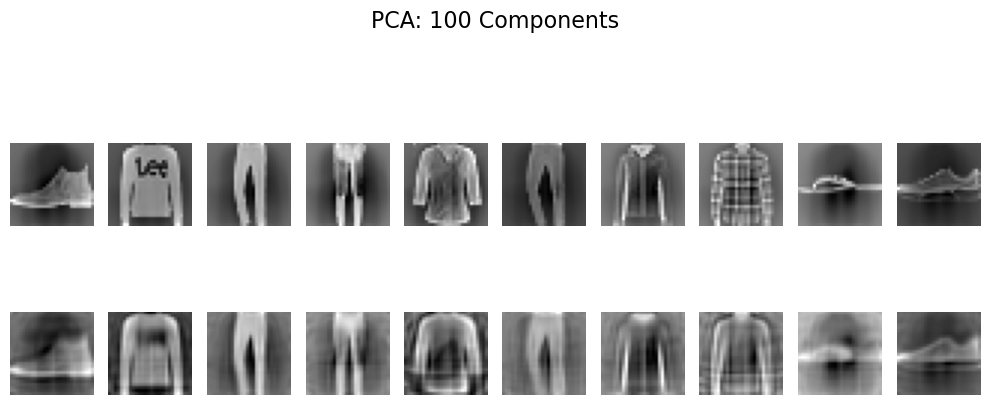

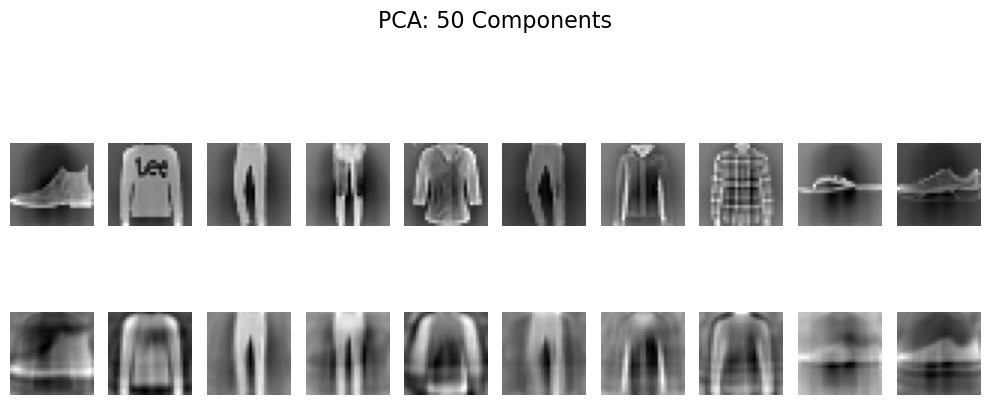

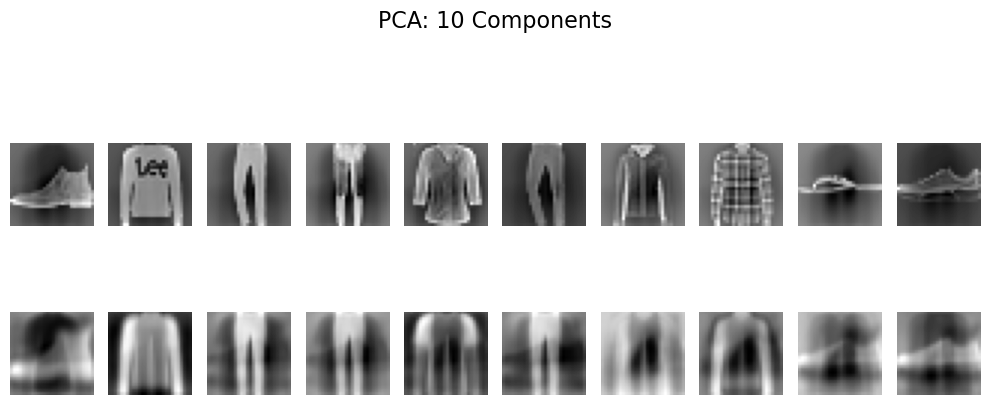

In [46]:
# Cell 4: Visualize Original vs Reconstructed Images (PCA)
def plot_images(original, reconstructed, title):
    plt.figure(figsize=(10, 5))
    for i in range(10):
        # Original images
        plt.subplot(2, 10, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

        # Reconstructed images
        plt.subplot(2, 10, i + 11)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap='gray')
        plt.axis('off')

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

for n_components in components:
    plot_images(x_test, reconstructed_images[n_components], f"PCA: {n_components} Components")


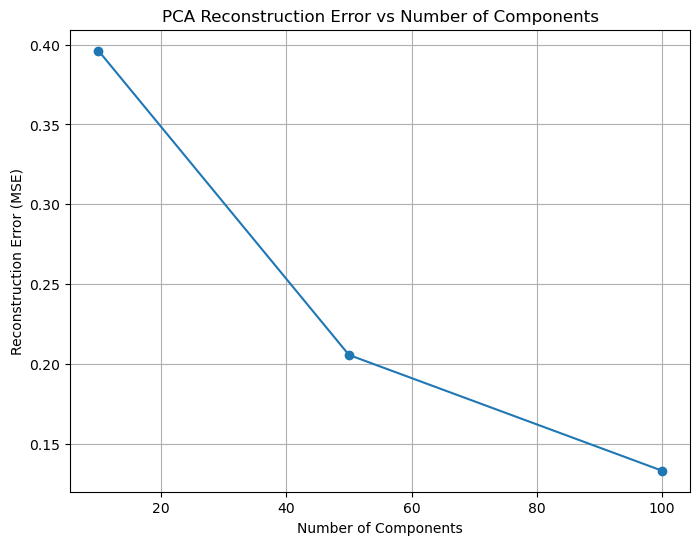

In [48]:
# Cell 5: Analysis of Reconstruction Error (PCA)
plt.figure(figsize=(8, 6))
plt.plot(components, errors, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Reconstruction Error (MSE)')
plt.title('PCA Reconstruction Error vs Number of Components')
plt.grid(True)
plt.show()


In [50]:
# Cell 6: Autoencoder Model Construction
def build_autoencoder(input_dim, encoding_dim):
    # Encoder
    input_layer = Input(shape=(input_dim,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(input_dim, activation='sigmoid')(encoded)

    # Autoencoder
    autoencoder = Model(inputs=input_layer, outputs=decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

autoencoders = {dim: build_autoencoder(784, dim) for dim in components}


In [52]:
# Cell 7: Train Autoencoders
epochs = 20
batch_size = 256
histories = {}

for encoding_dim, autoencoder in autoencoders.items():
    print(f"Training Autoencoder with {encoding_dim} latent units...")
    history = autoencoder.fit(
        x_train, x_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(x_test, x_test),
        verbose=1
    )
    histories[encoding_dim] = history.history


Training Autoencoder with 100 latent units...
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.8226 - val_loss: 0.6642
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6424 - val_loss: 0.6399
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6159 - val_loss: 0.6293
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6102 - val_loss: 0.6233
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6148 - val_loss: 0.6193
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.6057 - val_loss: 0.6164
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5993 - val_loss: 0.6143
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5952 - val_loss: 0.6127
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.5934 - val_loss: 0.6114
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5956 - val_loss: 0.6103
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.5905 - val_loss: 0.6097
Epoch 

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


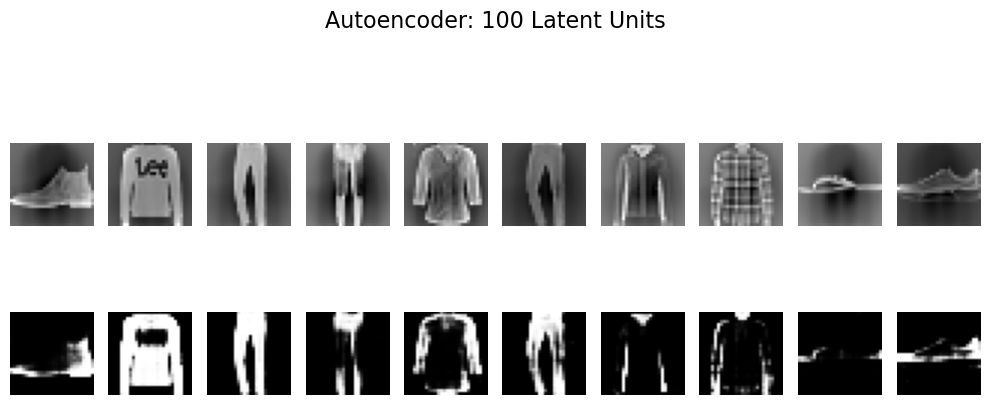

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


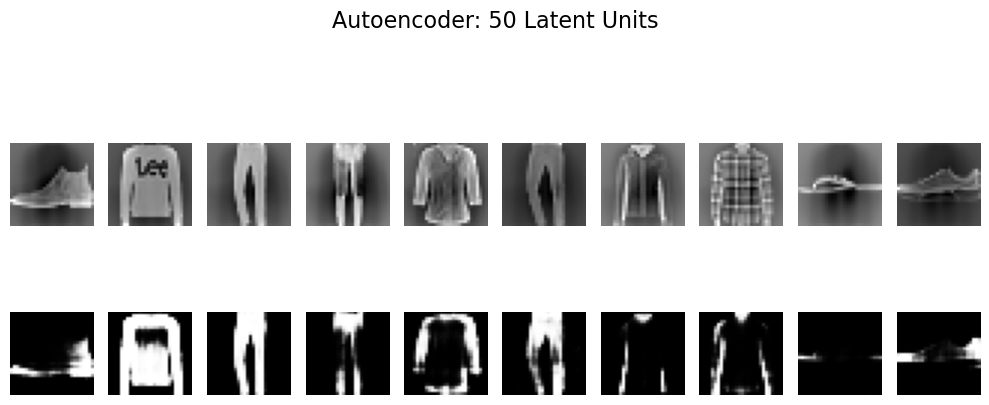

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


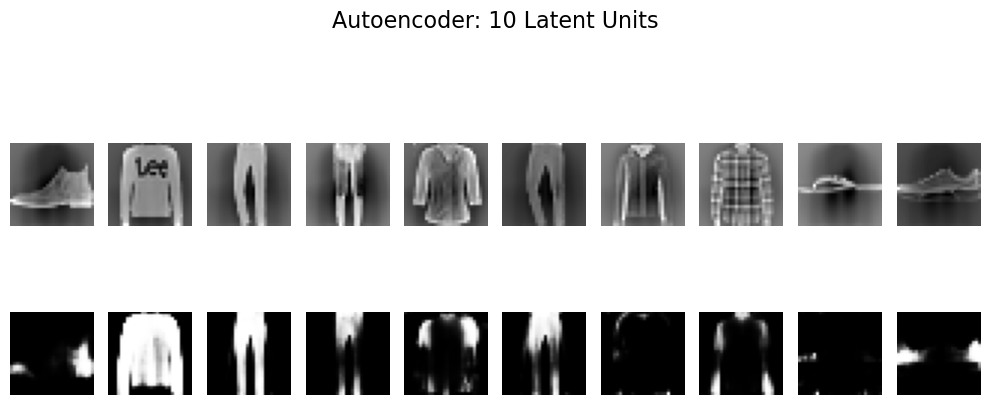

In [53]:
# Cell 8: Visualize Original vs Reconstructed Images (Autoencoder)
autoencoder_reconstructed = {}

for encoding_dim, autoencoder in autoencoders.items():
    reconstructed = autoencoder.predict(x_test)
    autoencoder_reconstructed[encoding_dim] = reconstructed
    plot_images(x_test, reconstructed, f"Autoencoder: {encoding_dim} Latent Units")


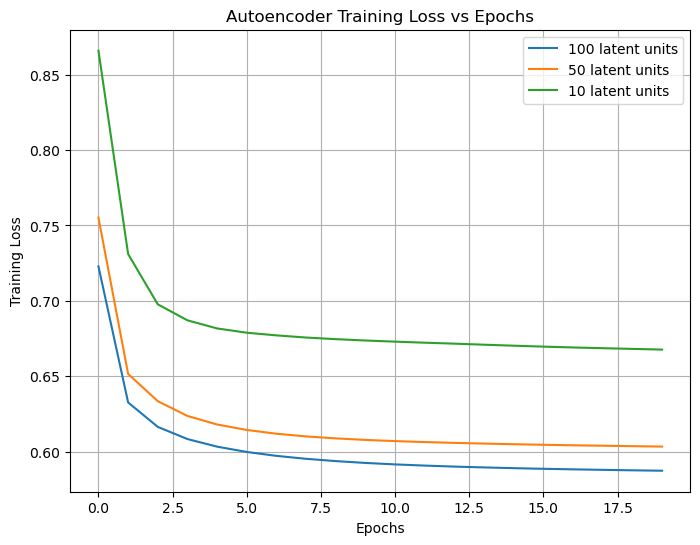

In [56]:
# Cell 9: Training Loss Visualization
plt.figure(figsize=(8, 6))
for encoding_dim, history in histories.items():
    plt.plot(history['loss'], label=f"{encoding_dim} latent units")

plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title('Autoencoder Training Loss vs Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [58]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA as SKPCA  # avoid name conflict
import matplotlib.pyplot as plt

# Function to extract encoded outputs from encoder
def extract_encoder(autoencoder_model):
    return Model(inputs=autoencoder_model.input, outputs=autoencoder_model.layers[1].output)

# Visualize latent space
def visualize_latent_space(encoder, x_data, labels=None, method='tsne', encoding_dim=10):
    latent = encoder.predict(x_data)

    if method == 'tsne':
        reducer = TSNE(n_components=2, random_state=42, perplexity=30)
    elif method == 'pca':
        reducer = SKPCA(n_components=2)
    else:
        raise ValueError("Method must be 'tsne' or 'pca'")

    latent_2d = reducer.fit_transform(latent)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], 
                          c=labels if labels is not None else 'blue', 
                          cmap='tab10', alpha=0.6)
    if labels is not None:
        plt.colorbar(scatter, label="Digit Label")
    plt.title(f"{method.upper()} of Autoencoder Latent Space ({encoding_dim} units)")
    plt.xlabel("Dim 1")
    plt.ylabel("Dim 2")
    plt.grid(True)
    plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


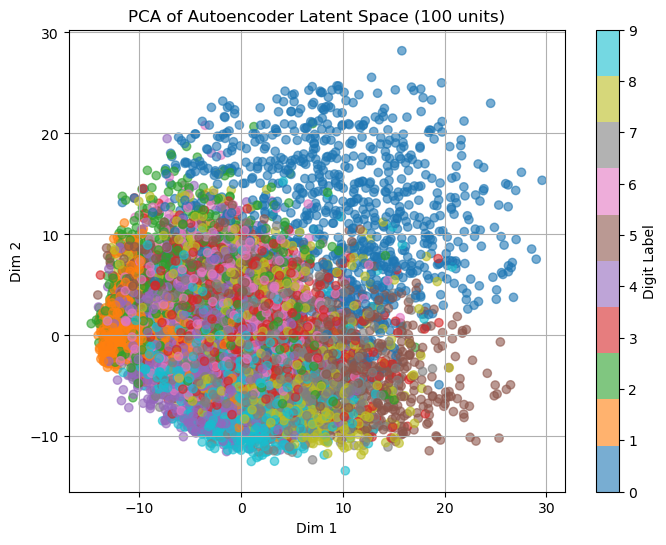

In [66]:
# Example: visualize for 100-dimensional autoencoder
from keras.datasets import mnist
(_, _), (x_test, y_test) = mnist.load_data()
x_test = x_test.reshape(-1, 784).astype('float32') / 255.

encoding_dim = 100  # change to 50 or 100 for others
encoder_model = extract_encoder(autoencoders[encoding_dim])
visualize_latent_space(encoder_model, x_test, labels=y_test, method='pca', encoding_dim=encoding_dim)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


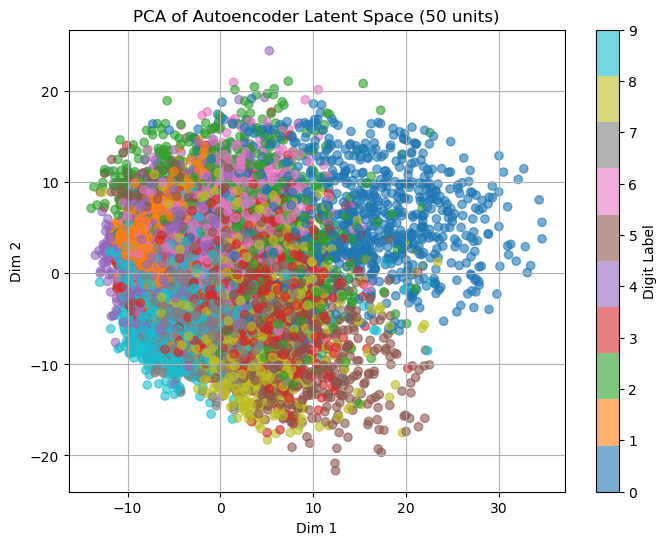

In [68]:
# Example: visualize for 50-dimensional autoencoder
from keras.datasets import mnist
(_, _), (x_test, y_test) = mnist.load_data()
x_test = x_test.reshape(-1, 784).astype('float32') / 255.

encoding_dim = 50  # change to 50 or 100 for others
encoder_model = extract_encoder(autoencoders[encoding_dim])
visualize_latent_space(encoder_model, x_test, labels=y_test, method='pca', encoding_dim=encoding_dim)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


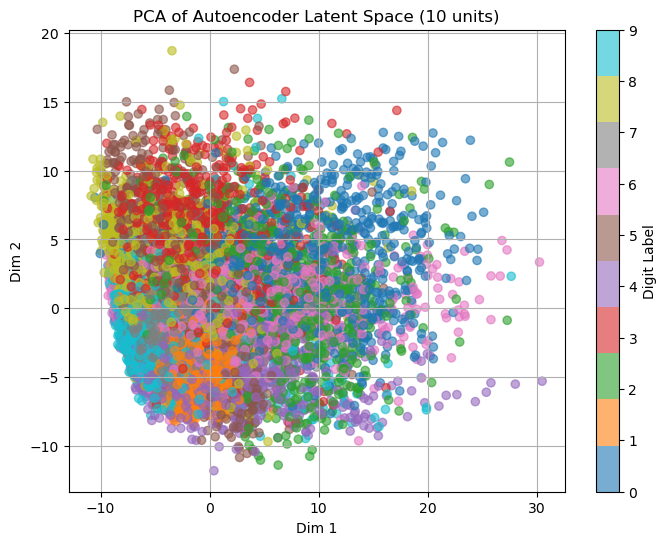

In [70]:
# Example: visualize for 10-dimensional autoencoder
from keras.datasets import mnist
(_, _), (x_test, y_test) = mnist.load_data()
x_test = x_test.reshape(-1, 784).astype('float32') / 255.

encoding_dim = 10  # change to 50 or 100 for others
encoder_model = extract_encoder(autoencoders[encoding_dim])
visualize_latent_space(encoder_model, x_test, labels=y_test, method='pca', encoding_dim=encoding_dim)
